# EDA Geoestadístico — ST-Kriging, Moran's I, Semivariogramas
## NO₂ Sentinel-5P + Estaciones DAGMA · Cali, Colombia

**Contenido:**
1. Imports y configuración
2. Carga datos DAGMA (ground truth)
3. Carga NO₂ S5P multianual
4. Extracción de NO₂ S5P en estaciones
5. Matriz de pesos espaciales
6. **Fig 1** — Índice de Moran global
7. **Fig 2** — Semivariograma omnidireccional
8. **Fig 3** — Semivariograma direccional (anisotropía)
9. **Fig 4** — Mapa NO₂ S5P + estaciones DAGMA
10. **Fig 5** — Correlación vs distancia entre estaciones
11. **Fig 6** — Mapa LISA (autocorrelación local)


## 1. Imports y configuración

In [2]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy import stats
import seaborn as sns
import rasterio

%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

# ── Rutas ──
ROOT         = Path().resolve().parent.parent   # ajusta según tu estructura
S5P_L3_DIR   = ROOT / "data" / "sentinel5p" / "l3"
DAGMA_CSV_DIR = ROOT / "data" / "dagma" / "raw"
OUT_DIR      = ROOT / "outputs" / "eda" / "geoestadistica"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

# ── Bbox ──
GRID_BBOX   = (-77.00, 5.00, -75.79, 2.99)
CALI_BOUNDS = (-76.60, 3.30, -76.40, 3.55)

def lonlat_to_pixel(lon, lat):
    return (int(round((GRID_BBOX[1] - lat) / 0.01)),
            int(round((lon - GRID_BBOX[0]) / 0.01)))

def save(name):
    p = OUT_DIR / f"{name}.png"
    plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()
    return p

print("Configuración lista ✅")


Configuración lista ✅


## 2. Carga de datos DAGMA (ground truth)

In [3]:
print("Cargando DAGMA...")
dfs = []
for f in sorted(DAGMA_CSV_DIR.glob("g4t8_*.csv")):
    for c in pd.read_csv(
        f,
        usecols=["nombre_est","msfl_code","med_concentracion_estandar",
                 "med_fecha_inicio","latitud","longitud"],
        chunksize=50_000,
        encoding="utf-8",
        on_bad_lines="skip",
    ):
        c["fecha"] = pd.to_datetime(c["med_fecha_inicio"], errors="coerce")
        c["valor"] = pd.to_numeric(c["med_concentracion_estandar"], errors="coerce")
        c = c.dropna(subset=["fecha", "valor"])
        dfs.append(c[["nombre_est","msfl_code","valor","fecha","latitud","longitud"]])

dagma = pd.concat(dfs, ignore_index=True)
dagma["fecha_dia"] = dagma["fecha"].dt.date

print(f"Registros cargados : {len(dagma):,}")
print(f"Estaciones únicas  : {dagma['nombre_est'].nunique()}")
print(f"Contaminantes      : {dagma['msfl_code'].unique().tolist()}")
dagma.head()


Cargando DAGMA...
Registros cargados : 3,829,785
Estaciones únicas  : 23
Contaminantes      : ['PLiquida', 'RGlobal', 'HAire2', 'VViento', 'P', 'DViento', 'SO2', 'PM10', 'TAire2', 'O3', 'PM2.5', 'HAire10', 'TAire10', 'NO2', 'NO', 'CO']


,nombre_est,msfl_code,valor,fecha,latitud,longitud,fecha_dia
0,ERA OBRERO,PLiquida,0.25,2020-01-01,3.457317,-76.506539,2020-01-01
1,ERA OBRERO,RGlobal,0.00,2020-01-01,3.457317,-76.506539,2020-01-01
2,PANCE,HAire2,92.90,2020-01-01,3.304517,-76.531252,2020-01-01
3,ERA OBRERO,VViento,1.30,2020-01-01,3.457317,-76.506539,2020-01-01
4,COMPARTIR,PLiquida,0.20,2020-01-01,3.428260,-76.466584,2020-01-01


## 3. Carga NO₂ Sentinel-5P multianual

In [4]:
print("Calculando NO₂ promedio multianual desde S5P...")
no2_sum = np.zeros((201, 121))
no2_cnt = np.zeros((201, 121))
processed = 0

for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    for md_dir in sorted(yd.iterdir()):
        if not md_dir.is_dir(): continue
        for dd in sorted(md_dir.iterdir()):
            if not dd.is_dir(): continue
            no2_file   = dd / "NO2.tif"
            cloud_file = dd / "CLOUD.tif"
            if not no2_file.exists() or not cloud_file.exists(): continue
            try:
                with rasterio.open(cloud_file) as src: cloud = src.read(1).astype(np.float32)
                with rasterio.open(no2_file)   as src: no2   = src.read(1).astype(np.float32)
                mask = (cloud <= 0.3) & (no2 > 0) & (no2 < 0.01)
                no2_sum[mask] += no2[mask]
                no2_cnt[mask] += 1
                processed += 1
                if processed % 2000 == 0:
                    print(f"  {processed} fechas procesadas...")
            except:
                pass

no2_mean = np.full((201, 121), np.nan)
valid = no2_cnt > 0
no2_mean[valid] = no2_sum[valid] / no2_cnt[valid] * 1e6

print(f"✅ {processed} fechas procesadas")
print(f"   Píxeles válidos : {valid.sum():,}")


Calculando NO₂ promedio multianual desde S5P...
✅ 1826 fechas procesadas
   Píxeles válidos : 24,236


## 4. Extracción de NO₂ S5P en estaciones DAGMA

In [5]:
print("Extrayendo NO₂ S5P en estaciones DAGMA...")
stations_no2  = dagma[(dagma["msfl_code"] == "NO2") & (dagma["valor"] > 0)]
station_means = (
    stations_no2
    .groupby(["nombre_est","latitud","longitud"])["valor"]
    .mean()
    .reset_index()
    .rename(columns={"valor": "dagma_no2_mean"})
)

s5p_vals = []
for _, r in station_means.iterrows():
    row, col = lonlat_to_pixel(r["longitud"], r["latitud"])
    s5p_vals.append(no2_mean[row, col] if 0 <= row < 201 and 0 <= col < 121 else np.nan)

station_means["s5p_no2"] = s5p_vals
station_means = station_means.dropna(subset=["s5p_no2"])

print(f"Estaciones con NO₂ S5P + DAGMA: {len(station_means)}")
station_means


Extrayendo NO₂ S5P en estaciones DAGMA...
Estaciones con NO₂ S5P + DAGMA: 5


,nombre_est,latitud,longitud,dagma_no2_mean,s5p_no2
0,ECA CTGO,4.748250,-75.912194,9.628189,19.470395
1,ESTACIÓN TULUÁ,4.066175,-76.196286,8.546698,18.012995
2,ESTACIÓN YUMBO,3.579075,-76.489558,10.178410,43.134358
3,MOVIL,3.510503,-76.308111,6.902067,24.550074
4,PALMIRA,3.537500,-76.300833,5.372398,28.371562


## 5. Construcción de la matriz de pesos espaciales

In [6]:
coords = station_means[["longitud","latitud"]].values
values = station_means["dagma_no2_mean"].values
n      = len(values)

inv_dist = 1 / (pdist(coords) + 1e-6)
dist_mat = squareform(inv_dist)
np.fill_diagonal(dist_mat, 0)

# Distancias en grados y diferencias cuadráticas (usadas en semivariogramas)
dists = squareform(pdist(coords))
diffs = squareform(pdist(values.reshape(-1, 1)) ** 2)

print(f"Número de estaciones : {n}")
print(f"Matriz de pesos      : {dist_mat.shape}")


Número de estaciones : 5
Matriz de pesos      : (5, 5)


## Fig 1 — Índice de Moran global

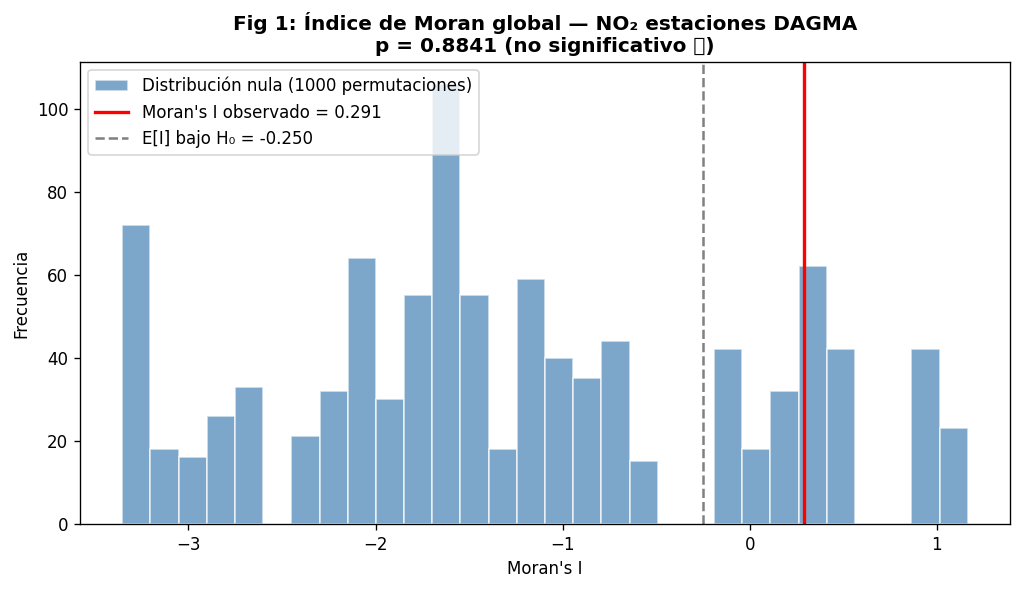

Moran's I = 0.2910  |  p = 0.8841


In [7]:
if n >= 5:
    row_sum    = dist_mat.sum(axis=1)
    w_row_std  = dist_mat / (row_sum[:, None] + 1e-10)

    y   = values - values.mean()
    sy2 = np.sum(y ** 2)
    moran_i = (n / sy2) * np.sum(w_row_std * y[:, None] * y[None, :])
    ei = -1 / (n - 1)

    # Test de permutaciones
    np.random.seed(42)
    perm_i = []
    for _ in range(1000):
        yp = np.random.permutation(y)
        perm_i.append((n / (yp**2).sum()) * np.sum(w_row_std * yp[:, None] * yp[None, :]))
    p_val = (np.sum(np.abs(perm_i) >= np.abs(moran_i)) + 1) / 1001

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(perm_i, bins=30, color="steelblue", edgecolor="white", alpha=0.7,
            label="Distribución nula (1000 permutaciones)")
    ax.axvline(moran_i, color="red", lw=2, label=f"Moran's I observado = {moran_i:.3f}")
    ax.axvline(ei, color="gray", ls="--", label=f"E[I] bajo H₀ = {ei:.3f}")
    ax.set_xlabel("Moran's I")
    ax.set_ylabel("Frecuencia")
    signi = "significativo ✅" if p_val < 0.05 else "no significativo ❌"
    ax.set_title(
        f"Fig 1: Índice de Moran global — NO₂ estaciones DAGMA\np = {p_val:.4f} ({signi})",
        fontweight="bold",
    )
    ax.legend()
    save("01_moran_global")
    print(f"Moran's I = {moran_i:.4f}  |  p = {p_val:.4f}")
else:
    print("Insuficientes estaciones (n < 5)")


## Fig 2 — Semivariograma omnidireccional

Modelo esférico — sill=5.52, range=0.1335°, nugget=0.00


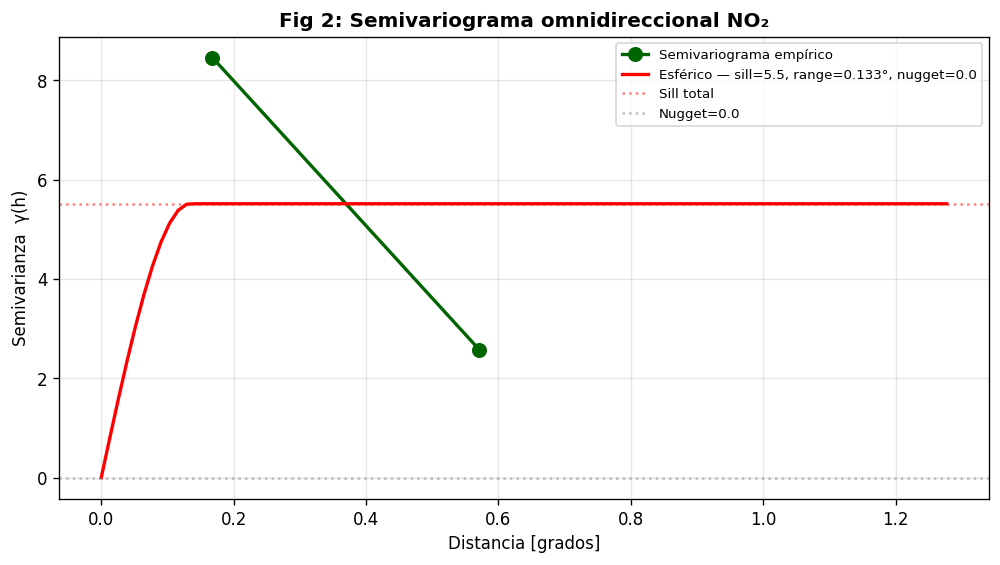

In [8]:
from scipy.optimize import curve_fit

def spherical(h, sill, range_val, nugget):
    return (nugget
            + sill * (1.5*(h/range_val) - 0.5*(h/range_val)**3) * (h <= range_val)
            + sill * (h > range_val))

if n >= 5:
    max_dist = np.percentile(dists[dists > 0], 80)
    bins     = np.linspace(0, max_dist, 20)
    gamma, bin_centers = [], []

    for i in range(len(bins) - 1):
        mask = (dists > bins[i]) & (dists <= bins[i+1])
        if mask.sum() >= 3:
            gamma.append(diffs[mask].mean() / 2)
            bin_centers.append((bins[i] + bins[i+1]) / 2)

    bc, gm = np.array(bin_centers), np.array(gamma)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(bc, gm, "o-", color="darkgreen", lw=2, markersize=8,
            label="Semivariograma empírico")

    try:
        popt, _ = curve_fit(
            lambda h, s, r, nug: spherical(h, s, r, nug),
            bc, gm,
            p0=[max(gm), max(bc)*0.5, 0],
            bounds=([0, 0, 0], [max(gm)*2, max(bc)*2, max(gm)]),
        )
        h_fit = np.linspace(0, max_dist, 100)
        ax.plot(h_fit, spherical(h_fit, *popt), "r-", lw=2,
                label=f"Esférico — sill={popt[0]:.1f}, range={popt[1]:.3f}°, nugget={popt[2]:.1f}")
        ax.axhline(popt[0] + popt[2], color="red",  ls=":", alpha=0.5, label="Sill total")
        ax.axhline(popt[2],           color="gray", ls=":", alpha=0.5, label=f"Nugget={popt[2]:.1f}")
        print(f"Modelo esférico — sill={popt[0]:.2f}, range={popt[1]:.4f}°, nugget={popt[2]:.2f}")
    except Exception as e:
        print(f"Ajuste no converge: {e}")

    ax.set_xlabel("Distancia [grados]")
    ax.set_ylabel("Semivarianza  γ(h)")
    ax.set_title("Fig 2: Semivariograma omnidireccional NO₂", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    save("02_semivariograma")


## Fig 3 — Semivariograma direccional (anisotropía)

In [9]:
if n >= 8:
    directions = [(0, "N-S (0°)"), (45, "NE-SW (45°)"), (90, "E-W (90°)"), (135, "NW-SE (135°)")]
    colors     = ["blue", "green", "red", "orange"]

    dx = coords[:, 0][:, None] - coords[:, 0][None, :]
    dy = coords[:, 1][:, None] - coords[:, 1][None, :]
    direction_angle = np.arctan2(dy, dx) * 180 / np.pi
    tolerance = 22.5

    fig, ax = plt.subplots(figsize=(10, 5))

    for (angle, label), col in zip(directions, colors):
        d_mask = (
            (np.abs(direction_angle - angle)       < tolerance) |
            (np.abs(direction_angle - angle - 180) < tolerance) |
            (np.abs(direction_angle - angle + 180) < tolerance)
        )
        dir_dists = dists[d_mask & (dists > 0)]
        dir_diffs = diffs[d_mask & (dists > 0)]
        if len(dir_dists) < 10:
            print(f"  {label}: insuficientes pares ({len(dir_dists)}), omitido")
            continue

        max_d = np.percentile(dir_dists, 90)
        b = np.linspace(0, max_d, 12)
        g_vals, bc_b = [], []
        for j in range(len(b) - 1):
            mask2 = (dir_dists > b[j]) & (dir_dists <= b[j+1])
            g_vals.append(dir_diffs[mask2].mean() / 2 if mask2.sum() >= 2 else np.nan)
            bc_b.append((b[j] + b[j+1]) / 2)

        ax.plot(bc_b, g_vals, "o-", lw=1.5, color=col, label=label, markersize=5)

    ax.set_xlabel("Distancia [grados]")
    ax.set_ylabel("Semivarianza")
    ax.set_title("Fig 3: Semivariograma direccional NO₂ (anisotropía)", fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    save("03_semivariograma_direccional")
else:
    print("Insuficientes estaciones (n < 8)")


Insuficientes estaciones (n < 8)


## Fig 4 — Mapa NO₂ S5P + estaciones DAGMA

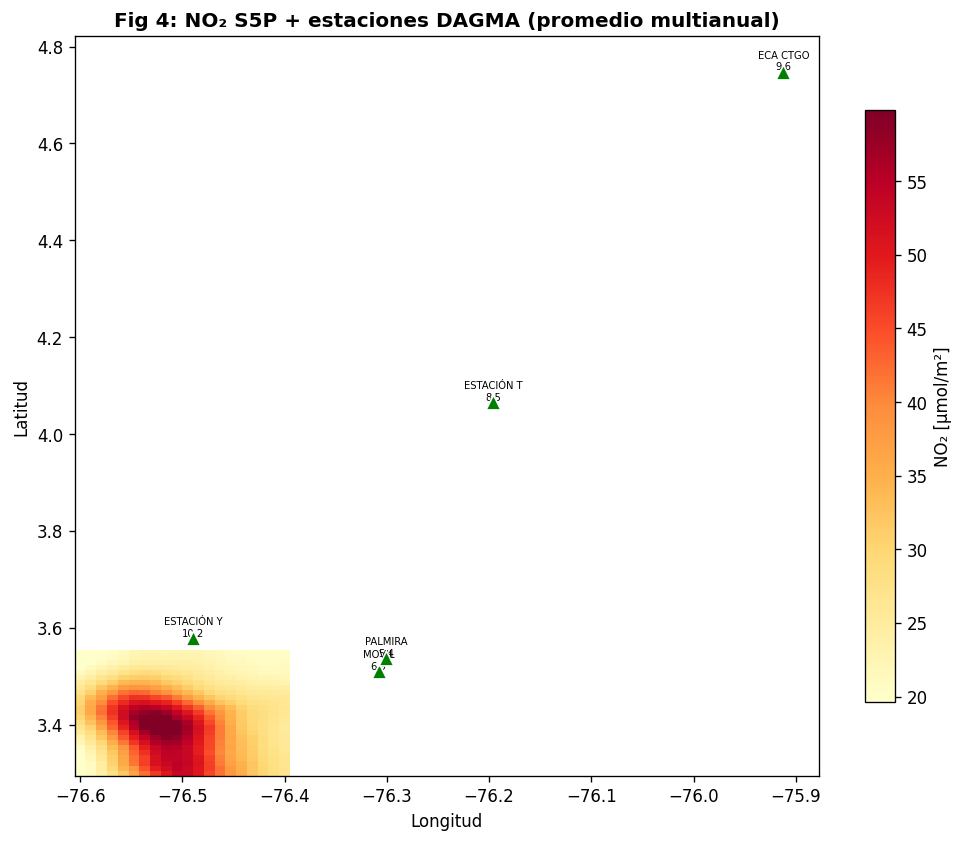

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/geoestadistica/04_mapa_idw_s5p_dagma.png')

In [10]:
# Extraer subgrilla de Cali
cali_left, cali_right = -76.60, -76.40
cali_bot,  cali_top   =   3.30,   3.55

cs = int(round((cali_left  - GRID_BBOX[0]) / 0.01))
ce = int(round((cali_right - GRID_BBOX[0]) / 0.01))
rs = int(round((GRID_BBOX[1] - cali_top) / 0.01))
re = int(round((GRID_BBOX[1] - cali_bot) / 0.01))
cs, ce = min(cs, ce), max(cs, ce)
rs, re = min(rs, re), max(rs, re)

cali_data = no2_mean[rs:re, cs:ce]
cali_lons = np.linspace(cali_left,  cali_right, ce - cs)
cali_lats = np.linspace(cali_bot,   cali_top,   re - rs)
lon_g, lat_g = np.meshgrid(cali_lons, cali_lats)

vmin = np.nanpercentile(cali_data, 2)
vmax = np.nanpercentile(cali_data, 98)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(lon_g, lat_g, cali_data,
                   cmap="YlOrRd", shading="auto",
                   vmin=vmin, vmax=vmax)

for _, r in station_means.iterrows():
    ax.scatter(r["longitud"], r["latitud"],
               c="green", s=80, marker="^",
               edgecolors="white", zorder=10)
    ax.annotate(
        f'{r["nombre_est"][:10]}\n{r["dagma_no2_mean"]:.1f}',
        (r["longitud"], r["latitud"]),
        fontsize=6, ha="center", va="bottom",
    )

plt.colorbar(im, ax=ax, label="NO₂ [µmol/m²]", shrink=0.8)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Fig 4: NO₂ S5P + estaciones DAGMA (promedio multianual)", fontweight="bold")
save("04_mapa_idw_s5p_dagma")


## Fig 5 — Correlación entre estaciones vs distancia

In [11]:
if n >= 3:
    try:
        corr_mat = np.atleast_2d(np.corrcoef(values))
        if corr_mat.size <= 1:
            raise ValueError("Matriz de correlación trivial")

        dist_km = squareform(pdist(coords)) * 111        # grados → km aprox.
        triu    = np.triu_indices(min(n, corr_mat.shape[0]), k=1)
        d_vec   = dist_km[triu]
        c_vec   = corr_mat[triu]
        if len(d_vec) < 2:
            raise ValueError("Pocos pares")

        sl, ic, r, p, _ = stats.linregress(d_vec, c_vec)
        xf = np.linspace(d_vec.min(), d_vec.max(), 100)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(d_vec, c_vec, s=50, c="steelblue", alpha=0.7, edgecolors="white",
                   label="Pares de estaciones")
        ax.plot(xf, sl * xf + ic, "r-", lw=2, label=f"Regresión: r = {r:.3f}, p = {p:.4f}")
        ax.axhline(0, color="gray", ls=":")
        ax.set_xlabel("Distancia [km]")
        ax.set_ylabel("Correlación de Pearson")
        ax.set_title("Fig 5: Correlación entre estaciones vs distancia", fontweight="bold")
        ax.legend()
        ax.grid(alpha=0.3)
        save("05_distancia_correlacion")
        print(f"Pendiente = {sl:.4f}  |  r = {r:.3f}  |  p = {p:.4f}")

    except Exception as e:
        print(f"Fig 5 omitida: {e}")
else:
    print("Insuficientes estaciones (n < 3)")


Fig 5 omitida: Matriz de correlación trivial


## Fig 6 — Mapa LISA (autocorrelación espacial local)

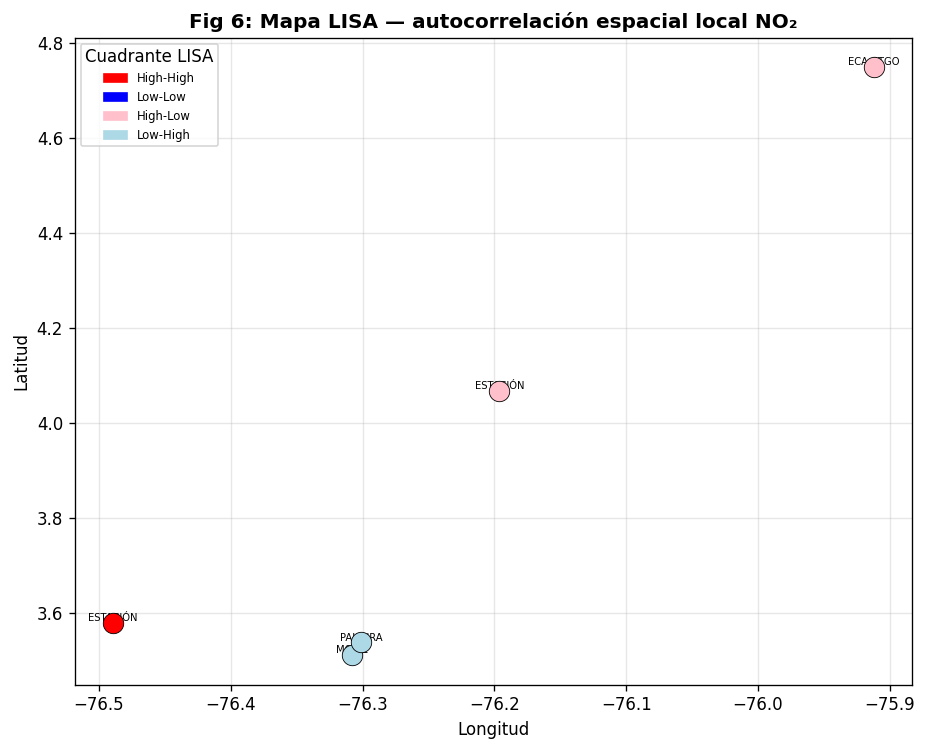

Distribución de cuadrantes:
  High-Low: 2 estaciones
  High-High: 1 estaciones
  Low-High: 2 estaciones


In [12]:
from matplotlib.patches import Patch

if n >= 3:
    # Calcular lag espacial ponderado por distancia inversa
    lags = np.zeros(n)
    for i in range(n):
        neighbors = dist_mat[i] > 0
        if neighbors.any():
            w_i = 1 / (dist_mat[i][neighbors] + 1e-6)
            w_i /= w_i.sum()
            lags[i] = np.sum(w_i * values[neighbors])

    # Estandarizar para cuadrantes Moran
    z_vals = (values - values.mean()) / (values.std() + 1e-10)
    z_lags = (lags   - lags.mean())   / (lags.std()   + 1e-10)

    QUAD_COLORS = {
        "High-High": "red",
        "Low-Low":   "blue",
        "High-Low":  "pink",
        "Low-High":  "lightblue",
    }

    def classify(zv, zl):
        if zv >= 0 and zl >= 0: return "High-High"
        if zv <  0 and zl <  0: return "Low-Low"
        if zv >= 0 and zl <  0: return "High-Low"
        return "Low-High"

    quadrants = [classify(z_vals[i], z_lags[i]) for i in range(n)]

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, (lon, lat) in enumerate(coords):
        ax.scatter(lon, lat,
                   c=QUAD_COLORS[quadrants[i]],
                   s=150, edgecolors="black", linewidth=0.5, zorder=5)
        ax.annotate(station_means.iloc[i]["nombre_est"][:8],
                    (lon, lat), fontsize=6, ha="center", va="bottom")

    legend_handles = [Patch(color=c, label=l) for l, c in QUAD_COLORS.items()]
    ax.legend(handles=legend_handles, fontsize=7, title="Cuadrante LISA")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.grid(alpha=0.3)
    ax.set_title("Fig 6: Mapa LISA — autocorrelación espacial local NO₂", fontweight="bold")
    save("06_mapa_lisa")

    # Resumen de cuadrantes
    from collections import Counter
    print("Distribución de cuadrantes:")
    for quad, cnt in Counter(quadrants).items():
        print(f"  {quad}: {cnt} estaciones")
else:
    print("Insuficientes estaciones (n < 3)")


## Resumen

In [13]:
pngs = sorted(OUT_DIR.glob("*.png"))
print(f"✅ EDA Geoestadístico completo")
print(f"   Directorio de salida : {OUT_DIR}")
print(f"   Gráficas generadas   : {len(pngs)}")
for p in pngs:
    print(f"   · {p.name}")


✅ EDA Geoestadístico completo
   Directorio de salida : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/geoestadistica
   Gráficas generadas   : 4
   · 01_moran_global.png
   · 02_semivariograma.png
   · 04_mapa_idw_s5p_dagma.png
   · 06_mapa_lisa.png
